In [63]:
## STEP 1: Loading/Importing relevant libraries

import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from scipy.stats import kruskal
import seaborn as sns

pd.set_option("display.max_columns", None)
## STEP 2: Load the data
# Loading the features
features = pd.read_csv(r'D:\TANZANIA_WATER_PROJECT\Data\features.csv')

# Loading the labels
labels = pd.read_csv(r'D:\TANZANIA_WATER_PROJECT\Data\labels.csv')
# Show the top 5 rows in features csv
print(f"Features csv: {display(display(features.head()))}")

# Show the top 5 rows in labels csv
print(f"Labels csv: {display(display(labels.head()))}")
features['installer'].nunique()
1896
## STEP 3: Pre-Cleaning EDA
def basic_checks(df):
    print("Features dataset shape: ", df.shape)
    print("Missing values summary: \n", df.isnull().sum())
    print("Basic info: ", df.info())
    print("Duplicates: ", df.duplicated().sum())
    print("Summary stats(Numerical)", display(df.describe().T))
    print("Summary stats(Categorical)", display(df.describe(include=['str','object']).T))

,id,amount_tsh,date_recorded,funder,gps_height,installer,longitude,latitude,wpt_name,num_private,basin,subvillage,region,region_code,district_code,lga,ward,population,public_meeting,recorded_by,scheme_management,scheme_name,permit,construction_year,extraction_type,extraction_type_group,extraction_type_class,management,management_group,payment,payment_type,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group
0,69572,6000.0,2011-03-14,Roman,1390,Roman,34.938093,-9.856322,none,0,Lake Nyasa,Mnyusi B,Iringa,11,5,Ludewa,Mundindi,109,True,GeoData Consultants Ltd,VWC,Roman,False,1999,gravity,gravity,gravity,vwc,user-group,pay annually,annually,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe
1,8776,0.0,2013-03-06,Grumeti,1399,GRUMETI,34.698766,-2.147466,Zahanati,0,Lake Victoria,Nyamara,Mara,20,2,Serengeti,Natta,280,NaN,GeoData Consultants Ltd,Other,NaN,True,2010,gravity,gravity,gravity,wug,user-group,never pay,never pay,soft,good,insufficient,insufficient,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe
2,34310,25.0,2013-02-25,Lottery Club,686,World vision,37.460664,-3.821329,Kwa Mahundi,0,Pangani,Majengo,Manyara,21,4,Simanjiro,Ngorika,250,True,GeoData Consultants Ltd,VWC,Nyumba ya mungu pipe scheme,True,2009,gravity,gravity,gravity,vwc,user-group,pay per bucket,per bucket,soft,good,enough,enough,dam,dam,surface,communal standpipe multiple,communal standpipe
3,67743,0.0,2013-01-28,Unicef,263,UNICEF,38.486161,-11.155298,Zahanati Ya Nanyumbu,0,Ruvuma / Southern Coast,Mahakamani,Mtwara,90,63,Nanyumbu,Nanyumbu,58,True,GeoData Consultants Ltd,VWC,NaN,True,1986,submersible,submersible,submersible,vwc,user-group,never pay,never pay,soft,good,dry,dry,machine dbh,borehole,groundwater,communal standpipe multiple,communal standpipe
4,19728,0.0,2011-07-13,Action In A,0,Artisan,31.130847,-1.825359,Shuleni,0,Lake Victoria,Kyanyamisa,Kagera,18,1,Karagwe,Nyakasimbi,0,True,GeoData Consultants Ltd,NaN,NaN,True,0,gravity,gravity,gravity,other,other,never pay,never pay,soft,good,seasonal,seasonal,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe


None

Features csv: None


,id,status_group
0,69572,functional
1,8776,functional
2,34310,functional
3,67743,non functional
4,19728,functional


None

Labels csv: None


Features dataset shape:  (59400, 40)
Missing values summary: 
 id                           0
amount_tsh                   0
date_recorded                0
funder                    3637
gps_height                   0
installer                 3655
longitude                    0
latitude                     0
wpt_name                     2
num_private                  0
basin                        0
subvillage                 371
region                       0
region_code                  0
district_code                0
lga                          0
ward                         0
population                   0
public_meeting            3334
recorded_by                  0
scheme_management         3878
scheme_name              28810
permit                    3056
construction_year            0
extraction_type              0
extraction_type_group        0
extraction_type_class        0
management                   0
management_group             0
payment                      0
payment

,count,mean,std,min,25%,50%,75%,max
id,59400.0,37115.131768,21453.128371,0.00000,18519.750000,37061.500000,55656.500000,7.424700e+04
amount_tsh,59400.0,317.650385,2997.574558,0.00000,0.000000,0.000000,20.000000,3.500000e+05
gps_height,59400.0,668.297239,693.116350,-90.00000,0.000000,369.000000,1319.250000,2.770000e+03
longitude,59400.0,34.077427,6.567432,0.00000,33.090347,34.908743,37.178387,4.034519e+01
latitude,59400.0,-5.706033,2.946019,-11.64944,-8.540621,-5.021597,-3.326156,-2.000000e-08
num_private,59400.0,0.474141,12.236230,0.00000,0.000000,0.000000,0.000000,1.776000e+03
region_code,59400.0,15.297003,17.587406,1.00000,5.000000,12.000000,17.000000,9.900000e+01
district_code,59400.0,5.629747,9.633649,0.00000,2.000000,3.000000,5.000000,8.000000e+01
population,59400.0,179.909983,471.482176,0.00000,0.000000,25.000000,215.000000,3.050000e+04
construction_year,59400.0,1300.652475,951.620547,0.00000,0.000000,1986.000000,2004.000000,2.013000e+03


Summary stats(Numerical) None


,count,unique,top,freq
date_recorded,59400,356,2011-03-15,572
funder,55763,1896,Government Of Tanzania,9084
installer,55745,2145,DWE,17402
wpt_name,59398,37399,none,3563
basin,59400,9,Lake Victoria,10248
subvillage,59029,19287,Madukani,508
region,59400,21,Iringa,5294
lga,59400,125,Njombe,2503
ward,59400,2092,Igosi,307
public_meeting,56066,2,True,51011


Summary stats(Categorical) None


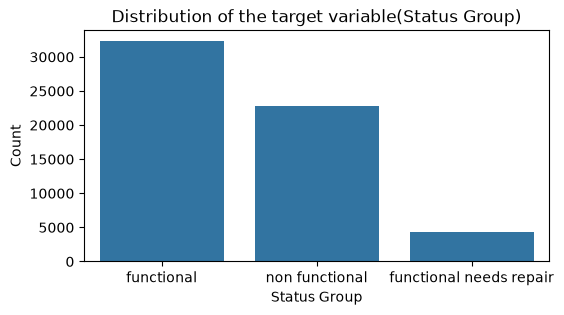

In [64]:
# Features
basic_checks(features)
# Convert the date recorded and construction_year column into a datetime data type
features['date_recorded'] = pd.to_datetime(features['date_recorded'], errors='coerce')
features['construction_year'] = pd.to_datetime(features['construction_year'], errors='coerce')
# merge the target and the features
data_df = pd.merge(features, labels, on='id', how='inner')
data_df.head()
data_df.dtypes
# Plot the distribution of the target.  
plt.figure(figsize=(6, 3))
sns.countplot(data=data_df, x='status_group')
plt.title("Distribution of the target variable(Status Group)")
plt.xlabel("Status Group")
plt.ylabel("Count")
plt.show()

In [65]:
# Types of classification problems.  
#- Binary classification - This is the case where you are classifying only 2 classes
# - Multiclass classification - Where you have 3 or more classes/groups
### Check for different categories in the categorical features
# Get the categorical columns
categorical_cols = data_df.select_dtypes(include=['str','object']).columns.tolist()

print(categorical_cols)

for column in categorical_cols:
    print('-'*40, column.upper(), '-'*40)
    print(data_df[column].unique())
data_df.shape
## STEP 4: Data Cleaning and Feature Engineering
data_df.columns
print(data_df['waterpoint_type'].unique())
print(data_df['waterpoint_type_group'].unique())

columns_to_keep = ['amount_tsh', 'date_recorded', 'gps_height', 'basin','region', 'population', 'scheme_management','permit', 'construction_year',
                    'extraction_type_class', 'payment_type', 'quality_group', 'quantity', 'source_type', 'waterpoint_type_group', 'status_group']


filtered_df = data_df[columns_to_keep] 
filtered_df = data_df[columns_to_keep] 

['funder', 'installer', 'wpt_name', 'basin', 'subvillage', 'region', 'lga', 'ward', 'public_meeting', 'recorded_by', 'scheme_management', 'scheme_name', 'permit', 'extraction_type', 'extraction_type_group', 'extraction_type_class', 'management', 'management_group', 'payment', 'payment_type', 'water_quality', 'quality_group', 'quantity', 'quantity_group', 'source', 'source_type', 'source_class', 'waterpoint_type', 'waterpoint_type_group', 'status_group']
---------------------------------------- FUNDER ----------------------------------------
<StringArray>
[               'Roman',              'Grumeti',         'Lottery Club',
               'Unicef',          'Action In A',  'Mkinga Distric Coun',
                 'Dwsp',                'Rwssp',             'Wateraid',
          'Isingiro Ho',
 ...
                 'Tove',           'Nerthlands',       'Nazalet Church',
 'Scharnhorstgymnasium',       'Wanginyi Water',                 'Cida',
  'Dwe/anglican Church',                 'Di

In [66]:


filtered_df.head()
# Create a month column from the date recorded column
filtered_df['month_recorded'] = filtered_df['date_recorded'].dt.month
filtered_df.head()
# Create a new column 'age', by getting the difference between date recorded and construction year
filtered_df['age'] = filtered_df['date_recorded'].dt.year - filtered_df['construction_year'].dt.year
nulls = (filtered_df.isnull().sum()/len(filtered_df))*100


In [67]:
nulls
### Null thresholds.  
#- 35% and below > you can fill the nulls:
   # - **Numerical columns:** Mean or median.      
       #  Use the mean if the data is normally distributed(Use median which is least affected by outliers).   
  #  - **Categorical columns:** Mode(most appearing).
#- 36% and above > Drop the whole column.       
#- 0 to 5% > You can drop the rows, or you can fill the rows.      

#*Note:** If filling the nulls distorts the original distribution, you can drop the whole column or rows if you have enough data.            
data_df['lga'].nunique()
# Drop the rows with the nulls
filtered_df = filtered_df.dropna(subset=['scheme_management','permit'])
### Recheck the categorical classes in the categorical columns
# Get the categorical columns
categorical_columns = filtered_df.select_dtypes(include=['str','object']).columns.tolist()

print(categorical_columns)

for column in categorical_columns:
    print('-'*40, column.upper(), '-'*40)
    print(filtered_df[column].unique())
# Standardize the entries 'Wami / Ruvu' and 'Ruvuma / Southern Coast' to 'Wami/Ruvu' and 'Ruvuma/Southern Coast'
filtered_df['basin'] = filtered_df['basin'].replace({'Wami / Ruvu':'Wami/Ruvu', 'Ruvuma / Southern Coast':'Ruvuma/Southern Coast'})
## STEP 5: Post-Cleaning EDA.    
#__Types of analysis visualization__. 
#- Univariate Analysis: Single column/variable analysis.      
#- Bivariate: Two variable analysis.    
#- Multivariate: More than two variables.     

['basin', 'region', 'scheme_management', 'permit', 'extraction_type_class', 'payment_type', 'quality_group', 'quantity', 'source_type', 'waterpoint_type_group', 'status_group']
---------------------------------------- BASIN ----------------------------------------
<StringArray>
[             'Lake Nyasa',           'Lake Victoria',
                 'Pangani', 'Ruvuma / Southern Coast',
                'Internal',         'Lake Tanganyika',
             'Wami / Ruvu',                  'Rufiji',
              'Lake Rukwa']
Length: 9, dtype: str
---------------------------------------- REGION ----------------------------------------
<StringArray>
[       'Iringa',          'Mara',       'Manyara',        'Mtwara',
         'Tanga',     'Shinyanga',        'Tabora',         'Pwani',
        'Ruvuma',   'Kilimanjaro',         'Rukwa',        'Kigoma',
         'Lindi',        'Dodoma',         'Mbeya',        'Arusha',
        'Mwanza',        'Kagera',       'Singida',      'Morogoro',
 'D

C:\Users\Wickliff Odoyo\AppData\Local\Temp\ipykernel_25932\812108582.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(filtered_df, x='status_group', palette='colorblind')


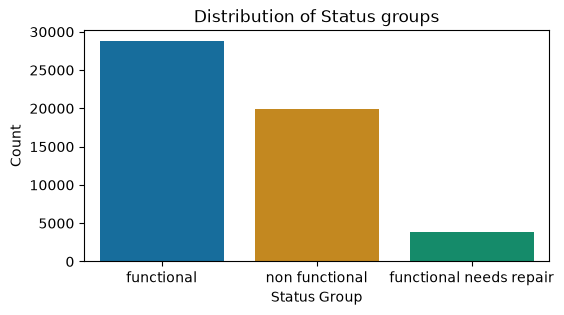

In [68]:
### 5.1 Univariate Analysis
#_Target variable_     
# Distribution of the target variable
plt.figure(figsize=(6,3))

sns.countplot(filtered_df, x='status_group', palette='colorblind')
plt.title('Distribution of Status groups')
plt.xlabel('Status Group')
plt.ylabel('Count')
plt.show()

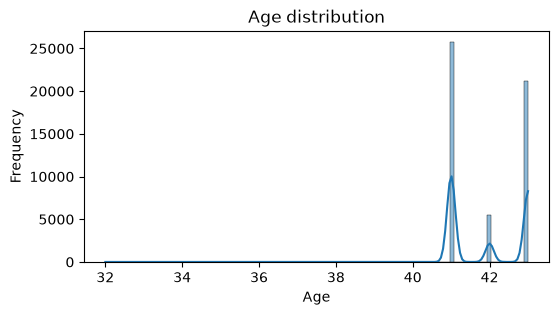

In [69]:
#Numeric features_
# Age 
plt.figure(figsize=(6,3))

sns.histplot(filtered_df, x='age', kde=True)
plt.title("Age distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()
#__Right and Left Skewed distributions__
#![Distributions](https://miro.medium.com/v2/resize:fit:1100/format:webp/1*XU3Kdl521XnWHECHZ7XOaQ.jpeg)


'[Normal' is not recognized as an internal or external command,
operable program or batch file.
's' is not recognized as an internal or external command,
operable program or batch file.


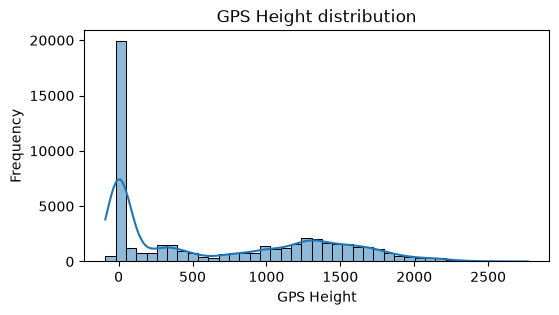

In [70]:
# Normal Distribution__
![Normal Distribtion](https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSy18r12Uk4eNJpjRSZe5_CvOTdvMu5YYAtinG4o0e0Yw&s=10)
plt.figure(figsize=(6,3))

sns.histplot(filtered_df, x='gps_height', kde=True)
plt.title("GPS Height distribution")
plt.xlabel("GPS Height")
plt.ylabel("Frequency")
plt.show()

C:\Users\Wickliff Odoyo\AppData\Local\Temp\ipykernel_25932\3854285977.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(filtered_df, x='payment_type', palette='Set2')


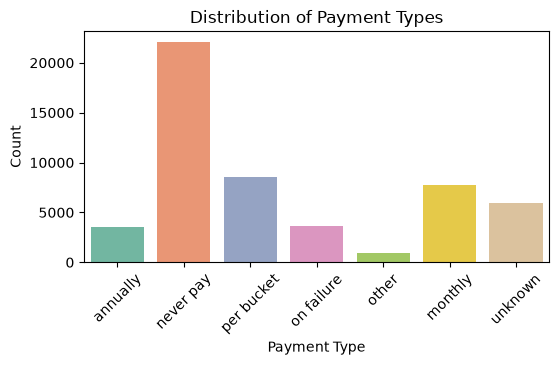

In [71]:
#_Categorical features_
# Payment type distribution
plt.figure(figsize=(6,3))

sns.countplot(filtered_df, x='payment_type', palette='Set2')
plt.title("Distribution of Payment Types")
plt.xlabel("Payment Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

              status_group   amount_tsh
0               functional  13960379.25
1           non functional   2724840.40
2  functional needs repair   1115148.00


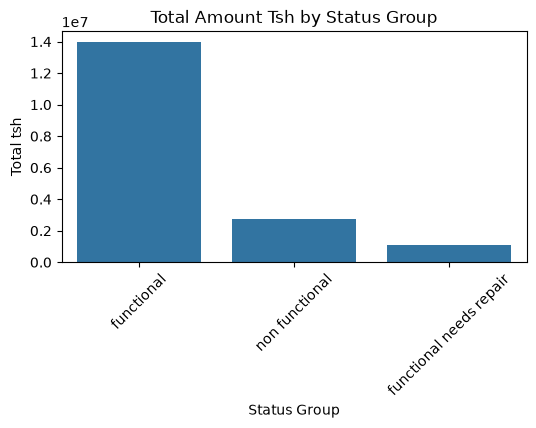

In [72]:
### 5.2 Bivariate Analysis
#_Numerical vs target column_
# Plot the worth of water in amount_tsh among the different sttus groups.    
status_sum_amount = filtered_df.groupby('status_group')['amount_tsh'].sum().sort_values(ascending=False).reset_index()

print(status_sum_amount)

# Plot 
plt.figure(figsize=(6,3))
sns.barplot(x='status_group', y='amount_tsh', data=status_sum_amount)
plt.title("Total Amount Tsh by Status Group")
plt.xlabel('Status Group')
plt.ylabel("Total tsh")
plt.xticks(rotation=45)
plt.show()

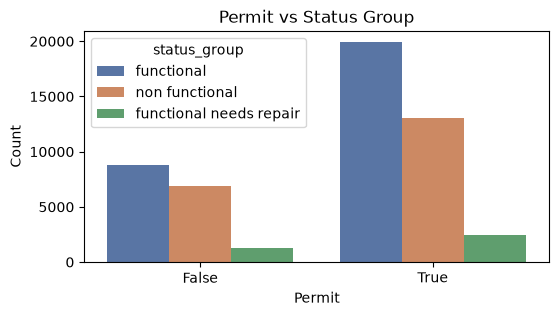

In [73]:
#_Categorical vs categorical_
plt.figure(figsize=(6,3))
sns.countplot(filtered_df, x='permit', hue='status_group', palette='deep')
plt.title("Permit vs Status Group")
plt.xlabel("Permit")
plt.ylabel("Count")
plt.show()

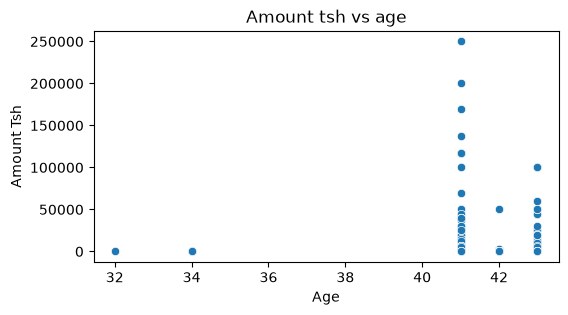

In [74]:
#_Numerical vs Numerical_
plt.figure(figsize=(6,3))
sns.scatterplot(filtered_df, x='age', y='amount_tsh')
plt.title("Amount tsh vs age")
plt.xlabel("Age")
plt.ylabel("Amount Tsh")
plt.show()

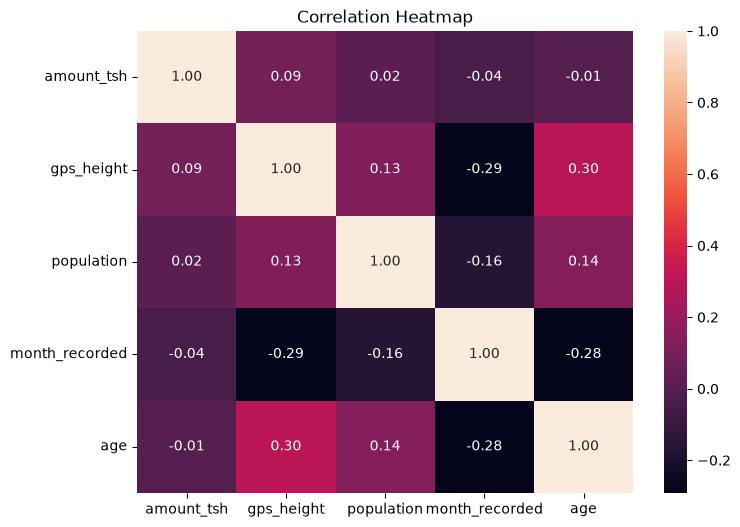

In [75]:
### 5.3 Multivariate Analysis

# Correlation heatmap 
numerical_cols = filtered_df.select_dtypes(include=['int','float']).columns.to_list()

correlation = filtered_df[numerical_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(correlation, annot=True, fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

#__Correlation interpretation__      
-1------------0------------------1      

#-1 to -0.6 => Strong negative correlation       
#-0.5 to -0.1 => Weak negative correlation.   
#0 = No correlation.      
#0.1 to 0.5 => Weak positive correlation.   
#0.6 to 1 => Strong positive correlation.  

#_Visual Example_.    
![VIsual COrrelation](https://www.investopedia.com/thmb/XBLXrcK1hn1RTS4mAvYMyifVKxI=/750x0/filters:no_upscale():max_bytes(150000):strip_icc():format(webp)/TC_3126228-how-to-calculate-the-correlation-coefficient-5aabeb313de423003610ee40.png)


## Hypothesis testing.   
#I#s a statistical method used to determine whether there is enough evidence in data to support a claim about a relationship between variables.     
#Hypothesis testing is helpful in:    
#- Feature Selection.   
#- EDA(to evaluate and see if the data makes statistical sense).   
#- Understanding relationships between variables.  
#- Reduce irrelevant features.   

#### The core idea of hypothesis testing.   
#__Null Hypothesis(H<sub>0</sub>):__ This is the default assumption that there's no effect, no relationship, no difference betwee groups.  
#_Example_ Gender and Loan Approval(Null hypothesis will be gender and loan approval are independent/there's no relationship. Meaning the feature gender doesn't affect target loan approval and the observed difference is random chance)       
#__Alternative Hypothesis(H<sub>1</sub>):__ This is what we want to prove, we as the researchers.    
#_Example_ Gender and Loan Approval are associated(meaning that there's predictive information from the feature gender).       

#__Definition of terms__      
#- Alpha/level of significance($\alpha$): Is a cutoff for statistical significance. mostly used alpha is 0.05/5%, 0.01/1%.   
#- p-value: Is the probability of observing results atleast as extreme as the current data assuming the null hypothesis is true.    


Judgement criteria.      
|Condition |Decision   |
|----------|-----------|
|p <= alpha|Reject H0  |
|p >  alpha|Fail the H0|    

- Type I Error(False Positive): When we reject a null hypothesis that is true.   
- Type II Error(False Negative): When we fail to reject null hypothesis.   

_How to choose the best hypothesis test_      
|Feature Type. |Target Variable        |Recommended test          |
|--------------|-----------------------|--------------------------|
|Numerical     |Numerical              |Correlation Heatmap       |
|Numerical     |Categorical(Binary)    |independent t-test        |
|Numerical     |Categorical(Multiclass)|ANOVA                     |
|Categorical.  |Categorical            |Chi-Square test of ind.   |     

__Common parametric hypothesis tests__      
- t-tests
- ANOVA
- Z-tests   

_Assumptions_     
- Continous data.    
- Normality 
- Independence(observation/categories must be independent of each other)
- Homogenity of variance(for independent t-test the variances of the two populations/groups must be roughly equal).     

__Common non-parametric tests__ 
Non-parametric tests are statistical methods that do not assume your data follows a specific distribution

- Mann-Whitney U test(independent t-test)         
- Kruskal-Wallis Test(One-Way ANOVA)     



__Numerical vs target__
numerical_cols

for col in numerical_cols:
    print('-'*35, col.upper(), '-'*35)
    h0 = f"There's no difference in the distribution of {col} amongst the status_groups"
    h1 = f"There's a difference in the distribution of {col} in atleast one status group"      

    alpha = 0.05     

    groups = [group[col].values for name, group in filtered_df.groupby('status_group')]

    stat, p = kruskal(*groups) 

    print("Test statistic", stat)
    print("P-Value", p)

    if p <= alpha:
        print(f"Reject the null hypothesis '{h0}'")
    else:
        print(f"Fail to reject the null hypothesis {h0}")
cars = {'Toyota':['Prado', 'Noah', 'Probox'],
        'VW':    ['Passat', 'Tiguan','Amarok']}

for key, value in cars.items():
    print(value)

In [76]:
# saving Data
import os

os.makedirs(r"D:\cleaned_data", exist_ok=True)

filtered_df.to_csv(r"D:\cleaned_data\data.csv", index=False)
import pandas as pd
import joblib
import numpy as np
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline  
from sklearn.svm import SVC  
from sklearn.compose import ColumnTransformer 
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
cleaned_df = pd.read_csv(r"D:\TANZANIA_WATER_PROJECT\Data\data.csv")

cleaned_df.head()

,amount_tsh,date_recorded,gps_height,basin,region,population,scheme_management,permit,construction_year,extraction_type_class,payment_type,quality_group,quantity,source_type,waterpoint_type_group,status_group,month_recorded,age
0,6000.0,2011-03-14,1390,Lake Nyasa,Iringa,109,VWC,False,1970-01-01 00:00:00.000001999,gravity,annually,good,enough,spring,communal standpipe,functional,3,41
1,0.0,2013-03-06,1399,Lake Victoria,Mara,280,Other,True,1970-01-01 00:00:00.000002010,gravity,never pay,good,insufficient,rainwater harvesting,communal standpipe,functional,3,43
2,25.0,2013-02-25,686,Pangani,Manyara,250,VWC,True,1970-01-01 00:00:00.000002009,gravity,per bucket,good,enough,dam,communal standpipe,functional,2,43
3,0.0,2013-01-28,263,Ruvuma/Southern Coast,Mtwara,58,VWC,True,1970-01-01 00:00:00.000001986,submersible,never pay,good,dry,borehole,communal standpipe,non functional,1,43
4,20.0,2011-03-13,0,Pangani,Tanga,1,VWC,True,1970-01-01 00:00:00.000002009,submersible,per bucket,salty,enough,other,communal standpipe,functional,3,41


In [77]:
# Drop the dates related columns.   
cleaned_df = cleaned_df.drop(columns=['date_recorded', 'construction_year'])
# Splitting data and seaparating target fro features
X = cleaned_df.drop(columns=['status_group'])
y = cleaned_df['status_group']
X_train, X_test, y_train, y_test = train_test_split(X,
                                                     y,
                                                      test_size=0.3,
                                                      stratify=y, # Stratify the target to maintain class ditribution in train and test sets
                                                       random_state=42)

In [78]:

# Splitting num_cols from categ_cols
# Numerical features
num_cols = X_train.select_dtypes(include=['int', 'float']).columns.tolist()

num_cols.remove('month_recorded')


In [79]:
le = LabelEncoder()

y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

In [80]:
# Categorical features
cat_cols = X_train.select_dtypes(include=['str', 'bool', 'object']).columns.tolist()
cat_cols.append('month_recorded')
num_pipeline = Pipeline([('scaler',StandardScaler())])

# If your datsset is not cleaned and contains missing values.    
# num_pipeline = Pipeline([('imputer', SimpleImputer(strategy='median'))('scaler',StandardScaler())])

cat_pipeline = Pipeline([('encoder', 
                          OneHotEncoder(handle_unknown='ignore'))])     

# handle_unknown ='ignore' to ignore errors during transformation if test set has unseen categories
preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])
pipelines = {
    'Logistic Regression': Pipeline([('preprocessor', preprocessor),
                                    ('model', LogisticRegression(random_state=42, max_iter=1000))]),
    'Random Forest': Pipeline([('preprocessor', preprocessor),
                                    ('model', RandomForestClassifier(random_state=42))]),
    
    'Decision Tree': Pipeline([('preprocessor', preprocessor),
                                    ('model', DecisionTreeClassifier(random_state=42))]),
    'SVM': Pipeline([('preprocessor', preprocessor),
                                    ('model', SVC(random_state=42, probability=True))]),
    'XGBoost': Pipeline([('preprocessor', preprocessor),
                                    ('model', XGBClassifier())]), 
    'Gradient Boosting': Pipeline([('preprocessor', preprocessor),
                                    ('model', GradientBoostingClassifier(random_state=42))])
}     

for name, pipeline in pipelines.items():
    print('-'*40, name.upper(), '-'*40)
    print(f"Training {name}...")
    pipeline.fit(X_train, y_train_encoded)

    print(f"Evaluating {name}...")
    y_pred = pipeline.predict(X_test)
    print("Classification report: \n", classification_report(y_test_encoded, y_pred, target_names=le.classes_))

    print(f"Trained and evaluated {name} model successfully!")
full_pipeline = Pipeline([('preprocessor', preprocessor),
                           ('model', RandomForestClassifier(random_state=42))])

---------------------------------------- LOGISTIC REGRESSION ----------------------------------------
Training Logistic Regression...
Evaluating Logistic Regression...
Classification report: 
                          precision    recall  f1-score   support

             functional       0.70      0.91      0.79      8620
functional needs repair       0.36      0.01      0.03      1139
         non functional       0.79      0.60      0.68      5994

               accuracy                           0.72     15753
              macro avg       0.62      0.51      0.50     15753
           weighted avg       0.71      0.72      0.69     15753

Trained and evaluated Logistic Regression model successfully!
---------------------------------------- RANDOM FOREST ----------------------------------------
Training Random Forest...
Evaluating Random Forest...
Classification report: 
                          precision    recall  f1-score   support

             functional       0.79      0.86  

d:\TANZANIA_WATER_PROJECT\tzwater\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Evaluating SVM...
Classification report: 
                          precision    recall  f1-score   support

             functional       0.75      0.92      0.82      8620
functional needs repair       0.63      0.12      0.20      1139
         non functional       0.83      0.68      0.75      5994

               accuracy                           0.77     15753
              macro avg       0.73      0.57      0.59     15753
           weighted avg       0.77      0.77      0.75     15753

Trained and evaluated SVM model successfully!
---------------------------------------- XGBOOST ----------------------------------------
Training XGBoost...
Evaluating XGBoost...
Classification report: 
                          precision    recall  f1-score   support

             functional       0.77      0.91      0.83      8620
functional needs repair       0.58      0.19      0.28      1139
         non functional       0.83      0.72      0.77      5994

               accuracy           

## STEP 7: Hyper-parameter tuning.    
Hyper-parameter tuning is the pracice of identifying and selecting optimal hyperparameters fro use in training machine learning models.      
_Random Forest HyperParameters_: 
n_estimators - Number of trees.     
max_depth - the maximum depth of the tree.    
min_samples_split: The minimum number of samples before a split happens.      
min_samples_leaf: the minimum number of samples required to be a leaf node. 

__CV or cross_validation__       
Assume this is a full training dataset that has been subdivided into smaller parts.     

Test 1
|Test| | | | |
|----|-|-|-|-|

Test 2
| |Test | | | |
|-|-----|-|-|-|

Test 3
| | |Test| | |
|-|-|----|-|-|

Test 4
| | | |Test| |
|-|-|-|----|-|

Test 5
| | | | |Test|
|-|-|-|-|----|   

__i). GridSearch CV__       
Grid search evaluates the model against every possible combination of predefined hyperparameter values.    

```python
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [5, 10, 15, 20, 25],
    'min_samples_split': [2, 5, 10, 20]
}  

grid_search = GridSearchCV(
    estimator = full_pipeline,
    parm_grid = param_grid,
    cv = 5,
    scoring ='f1_macro',
    n_jobs= -1
)

grid_search.fit(X_train, y_train_encoded)

# VIewing results
print("Best Hyper-Parameters: ", grid_search.best_params_)
print("Best Score: ", grid_search.best_score_)
```
_Limitation_   
- Extreme computational cost
- Impractical     

__ii). RandomizedCV__      
Instead of trying every every combination, it randomly samples from defined domain space, which is more efficient for large scale search spaces.     

```python 
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [5, 10, 15, 20, 25],
    'min_samples_split': [2, 5, 10, 20]
}  

random_search = RandomizedSearchCV(
    estimator=full_pipeline,
    parameter_distributions=param_distributions,
    n_iter = 20, # Number of random combinations to try
    cv = 5,
    scoring = 'f1_macro',
    random_stae=42,
    n_job=-1
)

In [81]:
full_pipeline.fit(X_train, y_train_encoded)



,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](3,)","[0,1,2]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['amount_tsh','gps_height','basin',...,'waterpoint_type_group', 'month_recorded','age']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pa

In [82]:
# Saving the encoded target
os.makedirs('../Models', exist_ok=True)
joblib.dump(le, '../Models/label_encoder.joblib')
joblib.dump(full_pipeline, '../Models/best_model.joblib')

['../Models/best_model.joblib']